In [93]:
#Practice 
'''
What I aim to do is take a large dataset and use pca to reduce the dimensions. How I aim to do this is by importing the data, converting it into
a DataFrame using pandas. I will then normalise an array of values from the dataset known as z and compute a covariance function on z. This will
mainly implement numpy. I will compute eigenvectors (principal directions) and eigenvalues from the covariance matrix and arrange them into descending
order again using numpy. All visualisations will use Matplotlib and Seaborn. After my eigenvalues and vectors are computed , I can reduce the cols to 
 the first 2 (pca1, pca2), as this contains the most important information. This forms the projection matrix in the shape (n_features, 2). I then
 project the noramlised data that I computed earlier (z) onto the projection matrix using matix mulitiplication to produce my 2D PCA presentsation. 
 
 '''
import pandas as pd
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
dataset = load_breast_cancer()
df = pd.DataFrame(dataset.data, columns = dataset.feature_names)

In [95]:
print("The first 5 rows are \n ",df.head())
print("The last 5 rows are \n",df.tail())
print("We desribe our dataset with the following:\n ",df.describe())
print("This is the shape of our dataset: ",df.shape)
print("This is the current amounnt of coloumns in our datset ", df.columns)



The first 5 rows are 
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst p

In [96]:
x = df.values
x_mean = np.mean(x, axis = 0)
x_sd = np.std(x, axis = 0)

z = (x - x_mean) / x_sd

c = np.cov(z.T)
print(z.shape)

(569, 30)


[]

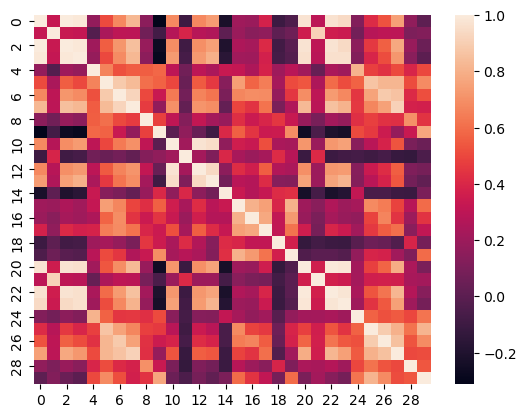

In [97]:
sns.heatmap(c)
plt.plot()

In [98]:
eigenvalues, eigenvectors = np.linalg.eig(c)
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

In [99]:
k = 2
w = eigenvectors[:, :k]
print("Projection matrix shape", w.shape)

Projection matrix shape (30, 2)


In [100]:
z_pca = z @ w
print("Projected data shape", z_pca.shape)

Projected data shape (569, 2)


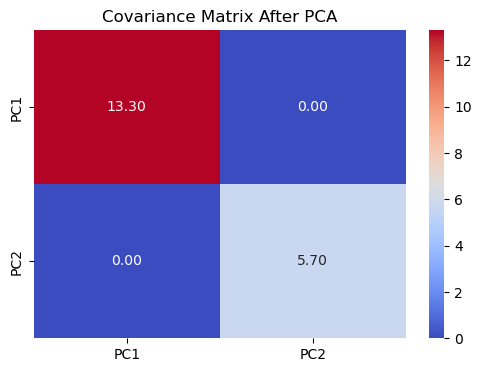

In [101]:
pca_cov = np.cov(z_pca.T)

plt.figure(figsize=(6, 4))
sns.heatmap(pca_cov, 
            annot=True,        
            fmt=".2f",
            cmap="coolwarm",
            xticklabels=["PC1", "PC2"],
            yticklabels=["PC1", "PC2"])
plt.title("Covariance Matrix After PCA")
plt.show()